In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

In [2]:
fc_part1 = pd.read_excel(
    "/Users/arjun/Library/CloudStorage/OneDrive-TechnischeHochschuleRosenheim/FC_Part1.xlsx",
    decimal=",",
)
fc_part2 = pd.read_excel(
    "/Users/arjun/Library/CloudStorage/OneDrive-TechnischeHochschuleRosenheim/FC_Part2.xlsx",
    decimal=",",
)
fc_init = pd.concat([fc_part1, fc_part2])
fc_init.index = pd.to_timedelta(fc_init["Time (h)"], unit="h")
df = fc_init.sort_index()
df = df[~df.index.duplicated(keep="first")]

df_hourly = df.resample("1h").mean().dropna()
fc = df_hourly.reset_index(drop=True)

In [3]:
polarisation_df = pd.read_excel(
    "/Users/arjun/Desktop/Project Thesis/FC1_FC2_Excel 2/FC2_With_Ripples_Excel/FC2_Pola_T000.xlsx"
)
pola_t00 = polarisation_df.sort_values(by="I (A)")
fc["U0"] = np.interp(fc["I (A)"], pola_t00["I (A)"], pola_t00["Ustack (V)"])
fc["voltage_loss_pct"] = (fc["U0"] - fc["Utot (V)"]) / fc["U0"] * 100
fc["target"] = fc["voltage_loss_pct"].rolling(window=20, min_periods=1).mean()

In [4]:
NON_CANDIDATE_COLS = {
    "U0","U1 (V)","U2 (V)","U3 (V)","U4 (V)","U5 (V)",
    "voltage_loss_pct",
    "target",
    "Utot (V)",
    "Time (h)","J (A/cmｲ)"
}
CANDIDATE_FEATURES = [
    c for c in fc.columns
    if c not in NON_CANDIDATE_COLS
]
print(f"Screening {len(CANDIDATE_FEATURES)} candidate columns:")
print(CANDIDATE_FEATURES)

Screening 17 candidate columns:
['I (A)', 'TinH2 (ｰC)', 'ToutH2 (ｰC)', 'TinAIR (ｰC)', 'ToutAIR (ｰC)', 'TinWAT (ｰC)', 'ToutWAT (ｰC)', 'PinAIR (mbara)', 'PoutAIR (mbara)', 'PoutH2 (mbara)', 'PinH2 (mbara)', 'DinH2 (l/mn)', 'DoutH2 (l/mn)', 'DinAIR (l/mn)', 'DoutAIR (l/mn)', 'DWAT (l/mn)', 'HrAIRFC (%)']


In [5]:
LAGS = [1, 6, 24]
ROLL_WINDOWS = [6, 24]
DIFF_LAGS = [1, 6, 24]
TEST_FRACTION = 0.2

screen = fc[CANDIDATE_FEATURES + ["target"]].copy()
for col in CANDIDATE_FEATURES:
    for lag in LAGS:
        screen[f"{col}_lag{lag}"] = screen[col].shift(lag)
    for win in ROLL_WINDOWS:
        screen[f"{col}_rollmean{win}"] = screen[col].rolling(win).mean()
        screen[f"{col}_rollstd{win}"] = screen[col].rolling(win).std()

screen["target_diff"] = screen["target"].diff()
for lag in DIFF_LAGS:
    screen[f"target_diff_lag{lag}"] = screen["target_diff"].shift(lag)

screen = screen.dropna().reset_index(drop=True)
feature_cols = [c for c in screen.columns if c not in ("target", "target_diff")]

/var/folders/dk/px_h_jkj3zs0bhpg3l7ttn5h0000gn/T/ipykernel_7419/2222100799.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  screen[f"{col}_lag{lag}"] = screen[col].shift(lag)
/var/folders/dk/px_h_jkj3zs0bhpg3l7ttn5h0000gn/T/ipykernel_7419/2222100799.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  screen[f"{col}_lag{lag}"] = screen[col].shift(lag)
/var/folders/dk/px_h_jkj3zs0bhpg3l7ttn5h0000gn/T/ipykernel_7419/2222100799.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fram

In [6]:
split_idx = int(len(screen) * (1 - TEST_FRACTION))
train_df = screen.iloc[:split_idx].reset_index(drop=True)

model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
)
model.fit(train_df[feature_cols], train_df["target_diff"], verbose=False)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)


SHAP importance (mean |value|), full ranking:
target_diff_lag1              0.013796
target_diff_lag6              0.001203
I (A)                         0.000939
ToutH2 (ｰC)_rollstd24         0.000750
I (A)_rollmean24              0.000653
target_diff_lag24             0.000640
DoutH2 (l/mn)                 0.000638
I (A)_rollstd24               0.000585
ToutAIR (ｰC)_rollstd6         0.000561
TinWAT (ｰC)_rollmean24        0.000525
PinAIR (mbara)_rollmean24     0.000435
TinWAT (ｰC)                   0.000422
DinAIR (l/mn)_rollmean24      0.000413
ToutH2 (ｰC)_rollmean24        0.000340
TinAIR (ｰC)_lag24             0.000340
TinWAT (ｰC)_rollstd24         0.000303
PoutH2 (mbara)                0.000297
TinH2 (ｰC)                    0.000291
DoutAIR (l/mn)_rollstd24      0.000290
HrAIRFC (%)                   0.000282
TinWAT (ｰC)_lag24             0.000265
DinH2 (l/mn)_rollmean6        0.000257
TinH2 (ｰC)_rollmean6          0.000251
ToutWAT (ｰC)_lag6             0.000220
I (A)_rollstd6   

/opt/anaconda3/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 65392 (\N{HALFWIDTH KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dk/px_h_jkj3zs0bhpg3l7ttn5h0000gn/T/ipykernel_7419/3345190662.py:26: UserWarning: Glyph 65392 (\N{HALFWIDTH KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_summary_train.png", dpi=150, bbox_inches="tight")
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65392 (\N{HALFWIDTH KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


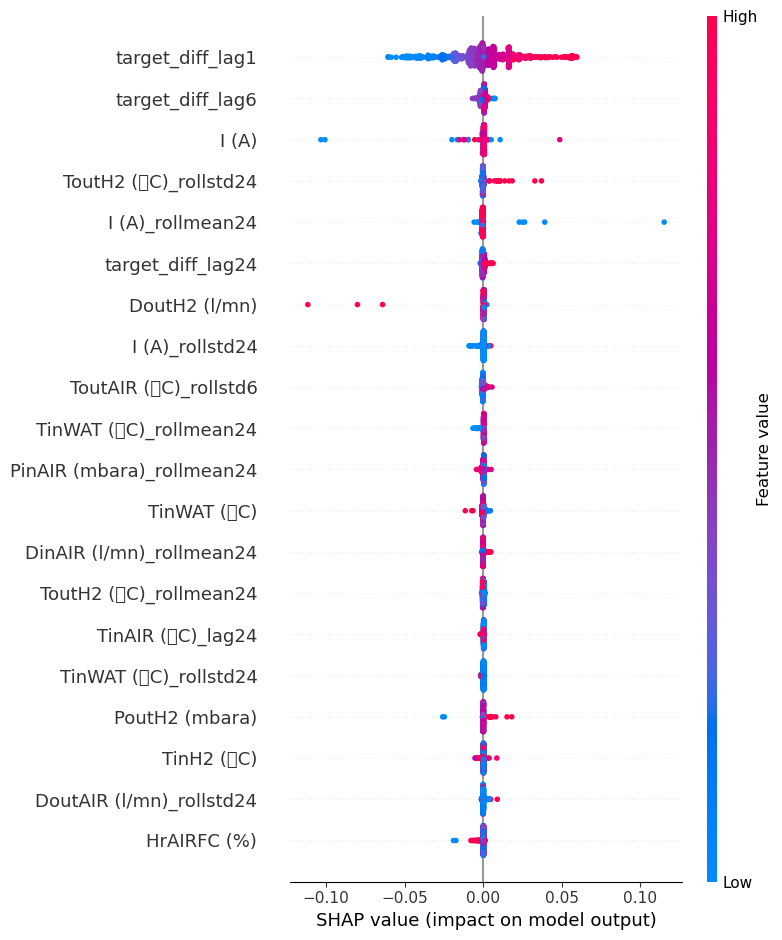


SHAP summary plot saved to shap_summary_train.png


In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(train_df[feature_cols])

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_cols
).sort_values(ascending=False)

print("\nSHAP importance (mean |value|), full ranking:")
with pd.option_context("display.max_rows", None):
    print(shap_importance)


def _base_channel(col: str) -> str:
    for f in CANDIDATE_FEATURES:
        if col == f or col.startswith(f + "_"):
            return f
    return "target_diff (autoregressive)"


grouped = shap_importance.groupby(_base_channel).sum().sort_values(ascending=False)
print("\nSHAP importance aggregated by physical channel:")
print(grouped)

shap.summary_plot(shap_values, train_df[feature_cols], show=False)
plt.tight_layout()
plt.savefig("shap_summary_train.png", dpi=150, bbox_inches="tight")
plt.show()